# 03 — Adversarial Robustness of the Metadata Detector

A white-box attacker rewrites their own ETM features in the model's SHAP order with values
resampled from clean training packages; DTM features are never touched. Accuracy is read on a
1:1 rebalanced test set, so 0.5 is the coin-flip floor.


## 1. Imports & config

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from common import (ECO_TITLES, MIN_VIEW_POS, SEED, make_models, make_views,
                    read_csv_literal)

ECO       = os.environ.get("ECO", "npm")
ECO_TITLE = ECO_TITLES[ECO]
IMBALANCE_RATIO = 10
PCT_STEPS      = list(range(0, 101, 10))
SHAP_EXPLAIN_N  = 300     # samples explained (all explainer types)
SHAP_BACKGROUND = 50      # background samples for KernelExplainer

ROOT    = Path("..")
PREP    = ROOT / "data" / "output" / ECO / "01_data_prep"
OUT_DIR = ROOT / "data" / "output" / ECO / "03_adversarial_robustness"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ["SVM", "GLM", "GBM", "DRF", "DL"]
ADV_SETS    = ["MeMPtec_E", "MeMPtec"]     # sets containing manipulable (ETM) features
t_nb = time.time()
print(f"{ECO_TITLE} | out: {OUT_DIR.resolve()}")


npm | out: C:\Users\amehs\Documents\ThesisAppendixVersion\data\output\npm\03_adversarial_robustness


## 2. Load the prepared corpus and build the attack splits

In [2]:
schema = json.loads((PREP / "schema.json").read_text(encoding="utf-8"))
df_all = read_csv_literal(PREP / "model_ready_dataset.csv")
ETM_FEATURES, DTM_FEATURES = schema["etm_features"], schema["dtm_features"]
FEATURE_SETS = {"MeMPtec_E": ETM_FEATURES, "MeMPtec_D": DTM_FEATURES,
                "MeMPtec": ETM_FEATURES + DTM_FEATURES}
assert schema["ecosystem"] == ECO and len(df_all) == schema["n_packages"]

label_arr = df_all["label"].astype(int).to_numpy()
VIEWS = make_views(label_arr)
print(f"{ECO_TITLE}: views = {list(VIEWS)}")

def get_X(sub, features):
    return sub[features].apply(pd.to_numeric, errors="coerce").values.astype(np.float32)

SPLITS = {}
for vname, v in VIEWS.items():
    sub = df_all[v["keep"]].reset_index(drop=True); y = v["y"]
    pos_i = np.flatnonzero(y == 1); neg_i = np.flatnonzero(y == 0)
    r = np.random.default_rng(SEED)
    take = min(IMBALANCE_RATIO * len(pos_i), len(neg_i))
    sel = np.sort(np.r_[pos_i, r.choice(neg_i, size=take, replace=False)])
    d, yy = sub.iloc[sel].reset_index(drop=True), y[sel]
    tr_i, te_i = train_test_split(np.arange(len(d)), test_size=0.2,
                                  stratify=yy, random_state=SEED)
    # the attack is scored on a 1:1 rebalanced test set so 0.5 is the coin-flip floor
    te_pos = te_i[yy[te_i] == 1]
    te_neg = np.random.default_rng(SEED).choice(te_i[yy[te_i] == 0],
                                                size=len(te_pos), replace=False)
    bal_i = np.sort(np.r_[te_pos, te_neg])
    SPLITS[vname] = {"df": d, "y": yy, "train": tr_i, "test": te_i, "bal": bal_i}
    print(f"  {vname:12s} train {len(tr_i):,} | test {len(te_i):,} | "
          f"balanced test {len(bal_i):,} ({yy[bal_i].mean():.1%} positive)")

npm: views = ['compromised', 'risky']
  compromised  train 18,955 | test 4,739 | balanced test 862 (50.0% positive)
  risky        train 44,748 | test 11,187 | balanced test 2,034 (50.0% positive)


## 3. Models

In [3]:
trained = {}
t0 = time.time()
for vname, sp in SPLITS.items():
    for fs_name, features in FEATURE_SETS.items():
        X = get_X(sp["df"], features)
        for mn in MODEL_ORDER:
            m = make_models()[mn]
            m.fit(X[sp["train"]], sp["y"][sp["train"]])
            acc = accuracy_score(sp["y"][sp["test"]], m.predict(X[sp["test"]]))
            trained[(vname, fs_name, mn)] = m
            print(f"  [{vname:11s}] {mn:4s} / {fs_name:10s} test_acc={acc:.4f} "
                  f"({time.time()-t0:.0f}s)")
print(f"\n{len(trained)} models trained in {(time.time()-t0)/60:.1f} min")

  [compromised] SVM  / MeMPtec_E  test_acc=0.9211 (1s)
  [compromised] GLM  / MeMPtec_E  test_acc=0.8563 (1s)
  [compromised] GBM  / MeMPtec_E  test_acc=0.9645 (9s)
  [compromised] DRF  / MeMPtec_E  test_acc=0.9669 (12s)
  [compromised] DL   / MeMPtec_E  test_acc=0.9489 (24s)
  [compromised] SVM  / MeMPtec_D  test_acc=0.9190 (24s)
  [compromised] GLM  / MeMPtec_D  test_acc=0.7831 (25s)
  [compromised] GBM  / MeMPtec_D  test_acc=0.9778 (26s)
  [compromised] DRF  / MeMPtec_D  test_acc=0.9768 (30s)
  [compromised] DL   / MeMPtec_D  test_acc=0.9610 (42s)
  [compromised] SVM  / MeMPtec    test_acc=0.9420 (43s)
  [compromised] GLM  / MeMPtec    test_acc=0.8652 (43s)
  [compromised] GBM  / MeMPtec    test_acc=0.9840 (46s)
  [compromised] DRF  / MeMPtec    test_acc=0.9812 (50s)
  [compromised] DL   / MeMPtec    test_acc=0.9654 (64s)
  [risky      ] SVM  / MeMPtec_E  test_acc=0.9117 (66s)
  [risky      ] GLM  / MeMPtec_E  test_acc=0.7391 (66s)
  [risky      ] GBM  / MeMPtec_E  test_acc=0.9289 (

## 4. SHAP attack ordering

In [4]:
def _normalise_sv(sv):
    # collapse any SHAP output shape to (n_samples, n_features) for the positive class
    if isinstance(sv, list):
        sv = sv[1]
    if hasattr(sv, "values"):
        sv = sv.values
    sv = np.asarray(sv)
    if sv.ndim == 3:
        sv = sv[:, :, 1]
    assert sv.ndim == 2, sv.shape
    return sv


def shap_rank(model_name, model, X_train, X_explain):
    # shap's KernelExplainer samples from numpy's LEGACY global RNG, not from a seeded
    # Generator -- without this line the SVM/DL attack ORDER differs on every call and the
    # degradation curves drift between runs.
    np.random.seed(SEED)
    if model_name in ("GBM", "DRF"):
        sv = _normalise_sv(shap.TreeExplainer(model).shap_values(X_explain[:SHAP_EXPLAIN_N]))
    elif model_name == "GLM":
        pre = Pipeline(model.steps[:-1])
        bg = pre.transform(X_train[:200]); ex = pre.transform(X_explain[:SHAP_EXPLAIN_N])
        sv = _normalise_sv(shap.LinearExplainer(model.named_steps["clf"], bg).shap_values(ex))
    else:  # SVM, DL -- model-agnostic on predict_proba
        bg = shap.sample(X_train, SHAP_BACKGROUND, random_state=SEED)
        ex = shap.KernelExplainer(model.predict_proba, bg)
        sv = _normalise_sv(ex.shap_values(X_explain[:SHAP_EXPLAIN_N], nsamples=100, silent=True))
    mean_abs = np.abs(sv).mean(axis=0)
    assert mean_abs.ndim == 1
    return np.argsort(mean_abs)[::-1].astype(int), mean_abs


shap_rankings = {}
t0 = time.time()
for vname, sp in SPLITS.items():
    for fs_name in ADV_SETS:
        features = FEATURE_SETS[fs_name]
        X = get_X(sp["df"], features)
        for mn in MODEL_ORDER:
            print(f"  SHAP [{vname:11s}] {mn:4s} / {fs_name:10s} ... ", end="", flush=True)
            ts = time.time()
            ranked, mean_abs = shap_rank(mn, trained[(vname, fs_name, mn)],
                                         X[sp["train"]], X[sp["test"]])
            shap_rankings[(vname, fs_name, mn)] = (ranked, mean_abs)
            print(f"top='{features[int(ranked[0])]}' ({time.time()-ts:.1f}s)")
print(f"\nSHAP rankings computed in {(time.time()-t0)/60:.1f} min")

  SHAP [compromised] SVM  / MeMPtec_E  ... top='readme_exist' (10.3s)
  SHAP [compromised] GLM  / MeMPtec_E  ... 

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


top='readme_exist' (0.0s)
  SHAP [compromised] GBM  / MeMPtec_E  ... top='readme_exist' (0.3s)
  SHAP [compromised] DRF  / MeMPtec_E  ... top='readme_exist' (58.0s)
  SHAP [compromised] DL   / MeMPtec_E  ... top='readme_exist' (8.7s)
  SHAP [compromised] SVM  / MeMPtec    ... top='package_age_days' (12.1s)
  SHAP [compromised] GLM  / MeMPtec    ... 

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


top='package_age_days' (0.0s)
  SHAP [compromised] GBM  / MeMPtec    ... top='package_age_days' (0.4s)
  SHAP [compromised] DRF  / MeMPtec    ... top='readme_length' (30.5s)
  SHAP [compromised] DL   / MeMPtec    ... top='package_age_days' (12.2s)
  SHAP [risky      ] SVM  / MeMPtec_E  ... top='readme_exist' (12.7s)
  SHAP [risky      ] GLM  / MeMPtec_E  ... 

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


top='readme_exist' (0.0s)
  SHAP [risky      ] GBM  / MeMPtec_E  ... top='readme_exist' (0.6s)
  SHAP [risky      ] DRF  / MeMPtec_E  ... top='readme_length' (282.4s)
  SHAP [risky      ] DL   / MeMPtec_E  ... top='readme_exist' (10.6s)
  SHAP [risky      ] SVM  / MeMPtec    ... top='package_modified_duration_days' (11.9s)
  SHAP [risky      ] GLM  / MeMPtec    ... 

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


top='package_modified_duration_days' (0.0s)
  SHAP [risky      ] GBM  / MeMPtec    ... top='package_modified_duration_days' (0.4s)
  SHAP [risky      ] DRF  / MeMPtec    ... top='readme_length' (255.2s)
  SHAP [risky      ] DL   / MeMPtec    ... top='package_modified_duration_days' (14.3s)

SHAP rankings computed in 12.0 min


## 5. The manipulation sweep

In [5]:
def run_adversarial(model, ranked_manip_idx, X_test, y_test, X_clean_train, seed=SEED):
    # seeded per call: re-running this cell reproduces the curve exactly
    r = np.random.default_rng(seed)
    mal = y_test == 1
    Xm = X_test.copy()
    accs = [accuracy_score(y_test, model.predict(Xm))]
    for fi in ranked_manip_idx:
        fi = int(fi)
        Xm[mal, fi] = r.choice(X_clean_train[:, fi], size=int(mal.sum()), replace=True)
        accs.append(accuracy_score(y_test, model.predict(Xm)))
    return accs


def resample_to_pct(accs, n_feats):
    return [accs[int(np.ceil(p / 100 * n_feats))] for p in PCT_STEPS]


adv_rows, adv_curves = [], {}
t0 = time.time()
for vname, sp in SPLITS.items():
    y = sp["y"]
    for fs_name in ADV_SETS:
        features = FEATURE_SETS[fs_name]
        X = get_X(sp["df"], features)
        X_clean_train = X[sp["train"]][y[sp["train"]] == 0]
        manip = {i for i, f in enumerate(features) if f in set(ETM_FEATURES)}
        for mn in MODEL_ORDER:
            ranked = shap_rankings[(vname, fs_name, mn)][0]
            ranked_manip = [i for i in ranked if i in manip]
            accs = run_adversarial(trained[(vname, fs_name, mn)], ranked_manip,
                                   X[sp["bal"]], y[sp["bal"]], X_clean_train)
            curve = resample_to_pct(accs, len(ranked_manip))
            adv_curves[(vname, fs_name, mn)] = curve
            for pct, a in zip(PCT_STEPS, curve):
                adv_rows.append({"view": vname, "feature_set": fs_name, "model": mn,
                                 "pct_manipulated": pct, "accuracy": a})
            print(f"  [{vname:11s}] {mn:4s} / {fs_name:10s} ({len(ranked_manip):2d} manipulable): "
                  f"0%->{curve[0]:.3f}  50%->{curve[5]:.3f}  100%->{curve[-1]:.3f}")

adv_df = pd.DataFrame(adv_rows)
adv_df.to_csv(OUT_DIR / "adversarial_results.csv", index=False)
print(f"\nsweep complete in {time.time()-t0:.0f}s -> {OUT_DIR/'adversarial_results.csv'}")

  [compromised] SVM  / MeMPtec_E  (36 manipulable): 0%->0.645  50%->0.521  100%->0.521
  [compromised] GLM  / MeMPtec_E  (36 manipulable): 0%->0.834  50%->0.563  100%->0.561
  [compromised] GBM  / MeMPtec_E  (36 manipulable): 0%->0.839  50%->0.509  100%->0.512
  [compromised] DRF  / MeMPtec_E  (36 manipulable): 0%->0.846  50%->0.499  100%->0.499
  [compromised] DL   / MeMPtec_E  (36 manipulable): 0%->0.804  50%->0.519  100%->0.522
  [compromised] SVM  / MeMPtec    (36 manipulable): 0%->0.765  50%->0.565  100%->0.567
  [compromised] GLM  / MeMPtec    (36 manipulable): 0%->0.879  50%->0.687  100%->0.704
  [compromised] GBM  / MeMPtec    (36 manipulable): 0%->0.921  50%->0.636  100%->0.635
  [compromised] DRF  / MeMPtec    (36 manipulable): 0%->0.905  50%->0.543  100%->0.535
  [compromised] DL   / MeMPtec    (36 manipulable): 0%->0.881  50%->0.594  100%->0.585
  [risky      ] SVM  / MeMPtec_E  (36 manipulable): 0%->0.521  50%->0.506  100%->0.507
  [risky      ] GLM  / MeMPtec_E  (36 manip

## 6. Figure — accuracy against the share of ETM features rewritten

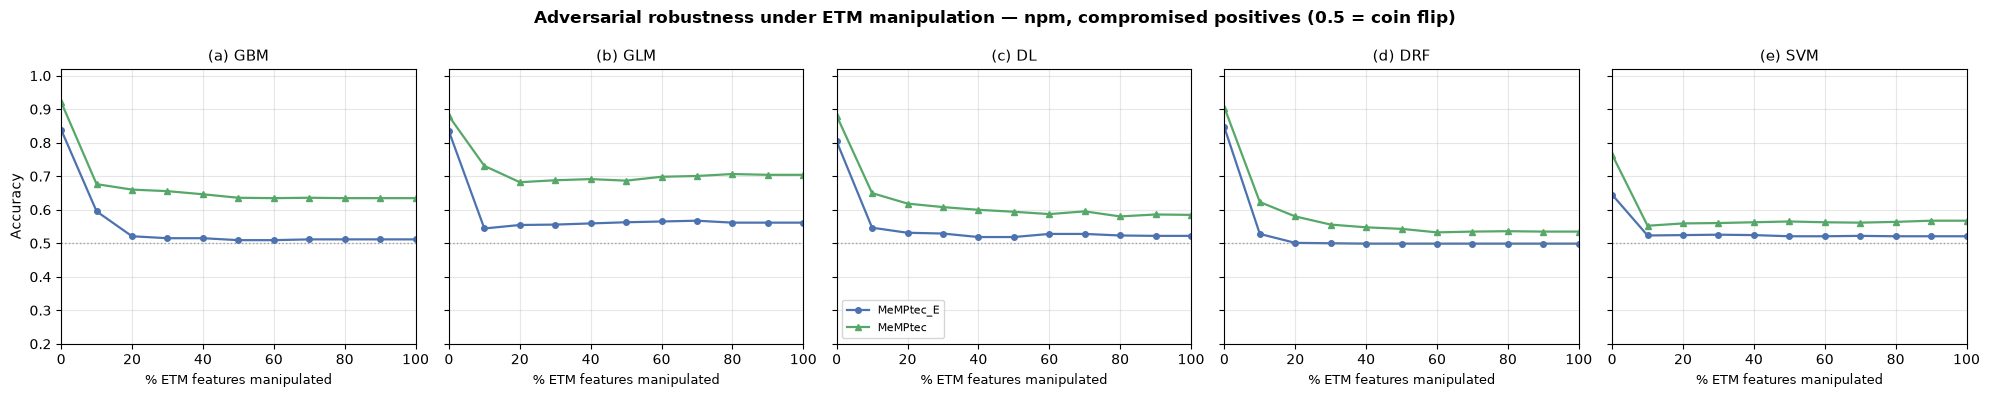

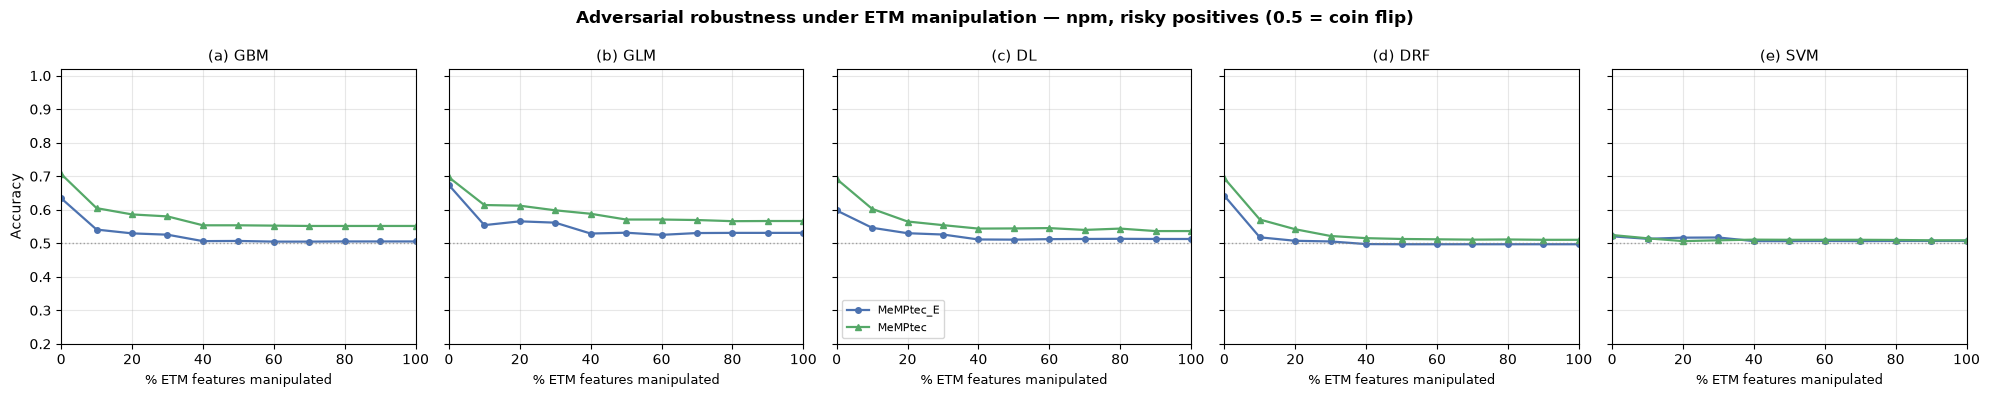

In [6]:
FS_COLORS  = {"MeMPtec_E": "#4C72B0", "MeMPtec": "#55A868"}
FS_MARKERS = {"MeMPtec_E": "o", "MeMPtec": "^"}
PANEL = ["GBM", "GLM", "DL", "DRF", "SVM"]

for vname in SPLITS:
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
    for ax, mn in zip(axes, PANEL):
        for fs_name in ADV_SETS:
            ax.plot(PCT_STEPS, adv_curves[(vname, fs_name, mn)],
                    color=FS_COLORS[fs_name], marker=FS_MARKERS[fs_name], ms=4,
                    lw=1.6, label=fs_name)
        ax.set_title(f"({'abcde'[PANEL.index(mn)]}) {mn}", fontsize=11)
        ax.set_xlabel("% ETM features manipulated", fontsize=9)
        ax.set_xlim(0, 100); ax.set_ylim(0.2, 1.02)
        ax.axhline(0.5, color="grey", ls=":", lw=1, alpha=0.7)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("Accuracy", fontsize=10)
    axes[2].legend(fontsize=8, loc="lower left")
    fig.suptitle(f"Adversarial robustness under ETM manipulation — {ECO_TITLE}, "
                 f"{vname} positives (0.5 = coin flip)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"adversarial_{vname}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)

## 7. Degradation table

In [7]:
rows = []
for (vname, fs_name, mn), curve in adv_curves.items():
    rows.append({"View": vname, "Model": mn, "Features": fs_name,
                 "Acc @ 0%": round(curve[0], 4), "Acc @ 50%": round(curve[5], 4),
                 "Acc @ 100%": round(curve[-1], 4),
                 "Drop 0->50%": round(curve[0] - curve[5], 4),
                 "Drop 0->100%": round(curve[0] - curve[-1], 4)})
deg = (pd.DataFrame(rows)
       .sort_values(["View", "Model", "Features"])
       .set_index(["View", "Model", "Features"]))
deg.to_csv(OUT_DIR / "degradation_summary.csv")
display(deg)

# does keeping the DTM block actually buy protection at full manipulation?
prot = []
for vname in SPLITS:
    for mn in MODEL_ORDER:
        e = adv_curves[(vname, "MeMPtec_E", mn)][-1]
        f = adv_curves[(vname, "MeMPtec", mn)][-1]
        prot.append({"view": vname, "model": mn, "MeMPtec_E @100%": round(e, 4),
                     "MeMPtec @100%": round(f, 4), "DTM protection": round(f - e, 4)})
prot_df = pd.DataFrame(prot)
prot_df.to_csv(OUT_DIR / "dtm_protection.csv", index=False)
print("\nProtection bought by retaining the DTM block (accuracy at 100% ETM manipulation):")
print(prot_df.to_string(index=False))
print(f"\nmean DTM protection: {prot_df['DTM protection'].mean():+.4f} accuracy")

Acc @ 0%  Acc @ 50%  Acc @ 100%  Drop 0->50%  \
View        Model Features                                                  
compromised DL    MeMPtec      0.8805     0.5940      0.5847       0.2865   
                  MeMPtec_E    0.8039     0.5186      0.5220       0.2854   
            DRF   MeMPtec      0.9049     0.5429      0.5348       0.3619   
                  MeMPtec_E    0.8457     0.4988      0.4988       0.3469   
            GBM   MeMPtec      0.9211     0.6357      0.6346       0.2854   
                  MeMPtec_E    0.8387     0.5093      0.5116       0.3295   
            GLM   MeMPtec      0.8794     0.6868      0.7042       0.1926   
                  MeMPtec_E    0.8341     0.5626      0.5615       0.2715   
            SVM   MeMPtec      0.7645     0.5650      0.5673       0.1995   
                  MeMPtec_E    0.6450     0.5209      0.5209       0.1241   
risky       DL    MeMPtec      0.6917     0.5442      0.5364       0.1475   
                  MeMPtec_E    0.5978     0.5108      0.5128       0.0870   
            DRF   MeMPtec      0.6937     0.5128      0.5103       0.1809   
                  MeMPtec_E    0.6416     0.4971      0.4971       0.1445   
            GBM   MeMPtec      0.7065     0.5536      0.5516       0.1529   
                  MeMPtec_E    0.6342     0.5069      0.5054       0.1273   
            GLM   MeMPtec      0.6967     0.5708      0.5664       0.1259   
                  MeMPtec_E    0.6735     0.5315      0.5310       0.1421   
            SVM   MeMPtec      0.5246     0.5103      0.5088       0.0143   
                  MeMPtec_E    0.5206     0.5064      0.5069       0.0143   

                             Drop 0->100%  
View        Model Features                 
compromised DL    MeMPtec          0.2958  
                  MeMPtec_E        0.2819  
            DRF   MeMPtec          0.3701  
                  MeMPtec_E        0.3469  
            GBM   MeMPtec          0.2865  
                  MeMPtec_E        0.3271  
            GLM   MeMPtec          0.1752  
                  MeMPtec_E        0.2726  
            SVM   MeMPtec          0.1972  
                  MeMPtec_E        0.1241  
risky       DL    MeMPtec          0.1554  
                  MeMPtec_E        0.0851  
            DRF   MeMPtec          0.1834  
                  MeMPtec_E        0.1445  
            GBM   MeMPtec          0.1549  
                  MeMPtec_E        0.1288  
            GLM   MeMPtec          0.1303  
                  MeMPtec_E        0.1426  
            SVM   MeMPtec          0.0157  
                  MeMPtec_E        0.0138


Protection bought by retaining the DTM block (accuracy at 100% ETM manipulation):
       view model  MeMPtec_E @100%  MeMPtec @100%  DTM protection
compromised   SVM           0.5209         0.5673          0.0464
compromised   GLM           0.5615         0.7042          0.1427
compromised   GBM           0.5116         0.6346          0.1230
compromised   DRF           0.4988         0.5348          0.0360
compromised    DL           0.5220         0.5847          0.0626
      risky   SVM           0.5069         0.5088          0.0020
      risky   GLM           0.5310         0.5664          0.0354
      risky   GBM           0.5054         0.5516          0.0462
      risky   DRF           0.4971         0.5103          0.0133
      risky    DL           0.5128         0.5364          0.0236

mean DTM protection: +0.0531 accuracy


## 8. Summary

In [9]:
summary = {"ecosystem": ECO, "views": ",".join(SPLITS),
            "n_etm": len(ETM_FEATURES), "n_dtm": len(DTM_FEATURES),
            "mean_dtm_protection": round(float(prot_df["DTM protection"].mean()), 4),
            "runtime_min": (time.time() - t_nb) / 60}
for vname in SPLITS:
    sub = deg.loc[vname]
    summary[f"{vname}_mean_drop_MeMPtec_E"] = round(
        float(sub.xs("MeMPtec_E", level="Features")["Drop 0->100%"].mean()), 4)
    summary[f"{vname}_mean_drop_MeMPtec"] = round(
        float(sub.xs("MeMPtec", level="Features")["Drop 0->100%"].mean()), 4)
    summary[f"{vname}_min_acc_at_100"] = round(
        float(min(adv_curves[(vname, fs, m)][-1] for fs in ADV_SETS for m in MODEL_ORDER)), 4)
pd.Series(summary).to_frame("value").to_csv(OUT_DIR / "summary.csv")
print(pd.Series(summary).to_string())

ecosystem                                        npm
views                              compromised,risky
n_etm                                             36
n_dtm                                             20
mean_dtm_protection                           0.0531
runtime_min                                15.948455
compromised_mean_drop_MeMPtec_E               0.2705
compromised_mean_drop_MeMPtec                  0.265
compromised_min_acc_at_100                    0.4988
risky_mean_drop_MeMPtec_E                      0.103
risky_mean_drop_MeMPtec                       0.1279
risky_min_acc_at_100                          0.4971
